# Analisis & Visualisasi Sinyal Audio (.wav)
Notebook ini terdiri dari 3 cell utama:
1. Import dependensi
2. Visualisasi audio (waveform, spektrum FFT, spektrogram STFT, mel-spektrogram)
3. Downsampling: Naive Decimation vs Resampling Standar (anti-aliasing)


In [1]:
# ============================================================
# CELL 1: IMPORT DEPENDENSI
# ============================================================

# os digunakan untuk mengelola file, navigasi direktori, dan yang lainnya
import os

# numpy digunakan untuk operasi numerik (array, FFT manual, normalisasi, dsb)
import numpy as np

# scipy.signal digunakan untuk operasi sinyal, termasuk resampling standar (resample_poly)
import scipy.signal as signal

# librosa digunakan untuk load file audio serta ekstraksi fitur (STFT, mel-spectrogram, resample)
import librosa

# librosa.display berisi fungsi bantu untuk menampilkan waveform & spektrogram dengan sumbu yang benar
import librosa.display

# matplotlib.pyplot digunakan untuk membuat semua plot/visualisasi
import matplotlib.pyplot as plt

# Audio & display dari IPython digunakan untuk memutar audio langsung di dalam notebook
# Image untuk menampilkan gambar di dalam notebook
from IPython.display import Audio, display, Image

# Atur ukuran default figure matplotlib agar semua plot nanti lebih mudah dibaca
plt.rcParams['figure.figsize'] = (14, 5)

# Path ke file audio .wav yang ingin dianalisis -> GANTI sesuai lokasi file kamu
AUDIO_PATH = "audio_original.wav"

print("Semua dependensi berhasil di-import.")


Semua dependensi berhasil di-import.


Sample rate : 44100 Hz
Durasi      : 14.605 detik
Jumlah sample: 644096

Amplitudo minimal  : -0.592
Amplitudo maksimal : 1.000


Frekuensi dengan energi paling konsisten: 107.7 Hz


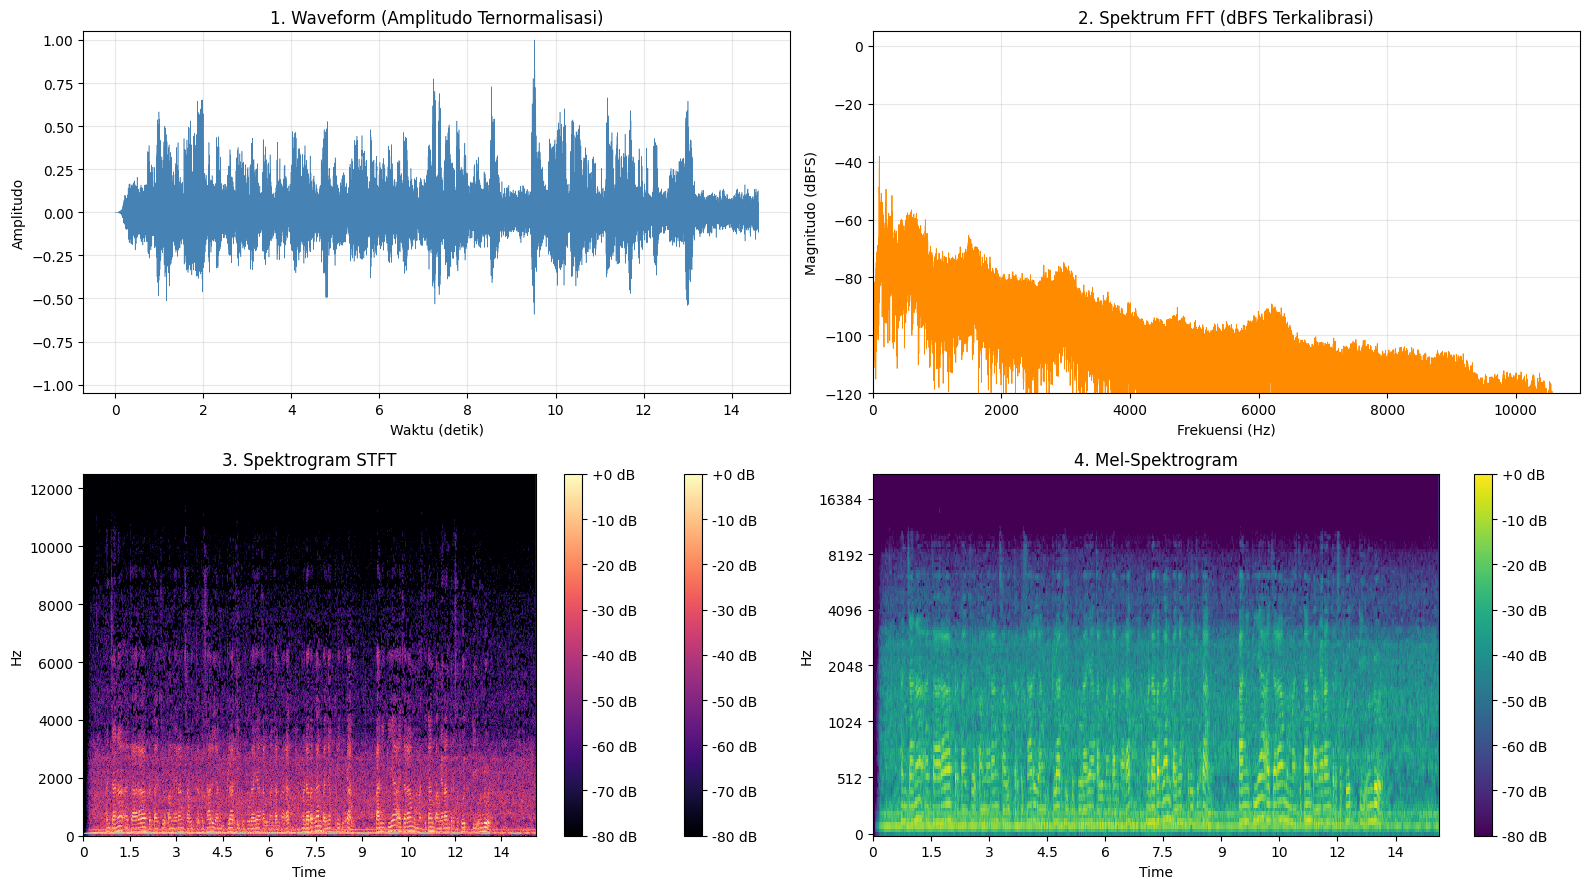

In [2]:
# ============================================================
# CELL 2: VISUALISASI AUDIO (4 TAMPILAN)
# 1) Waveform (amplitudo ternormalisasi vs waktu)
# 2) Spektrum FFT (dBFS terkalibrasi)
# 3) Spektrogram STFT
# 4) Mel-Spektrogram
# ============================================================

# Load file audio; sr=None artinya sample rate ASLI file dipertahankan (tidak di-resample otomatis)
# mono=True akan menggabungkan channel menjadi 1 channel (mono) jika audio stereo
y, sr = librosa.load(AUDIO_PATH, sr=None, mono=True)
# Normalisasi sinyal terhadap nilai absolut maksimum agar rentang menjadi [-1, 1]
y_norm = y / np.max(np.abs(y))


# Tampilkan info dasar audio: durasi, sample rate, jumlah sample
print(f"Sample rate : {sr} Hz")
print(f"Durasi      : {len(y)/sr:.3f} detik")
print(f"Jumlah sample: {len(y)}")
print(f"\nAmplitudo minimal  : {np.min(y_norm):.3f}")
print(f"Amplitudo maksimal : {np.max(y_norm):.3f}")

# Putar audio asli langsung di notebook untuk verifikasi pendengaran
display(Audio(y, rate=sr))

# Siapkan grid 2x2 untuk menampung ke-4 visualisasi
fig, axs = plt.subplots(2, 2, figsize=(16, 9))

# ------------------------------------------------------------------
# (1) WAVEFORM - amplitudo ternormalisasi vs waktu
# ------------------------------------------------------------------
# Buat sumbu waktu (dalam detik) sesuai jumlah sample dan sample rate
t = np.arange(len(y_norm)) / sr

# Plot waveform: sumbu x = waktu (detik), sumbu y = amplitudo ternormalisasi
axs[0, 0].plot(t, y_norm, linewidth=0.4, color="steelblue")
axs[0, 0].set_title("1. Waveform (Amplitudo Ternormalisasi)")
axs[0, 0].set_xlabel("Waktu (detik)")
axs[0, 0].set_ylabel("Amplitudo")
axs[0, 0].set_ylim(-1.05, 1.05)  # batasi sumbu y karena sinyal sudah dinormalisasi ke [-1, 1]
axs[0, 0].grid(alpha=0.3)

# ------------------------------------------------------------------
# (2) SPEKTRUM FFT - dBFS terkalibrasi
# ------------------------------------------------------------------
N = len(y)  # jumlah total sample, dipakai untuk normalisasi FFT

# rfft (real FFT) cukup dipakai karena sinyal audio bernilai real -> hasil FFT simetris,
# rfft hanya mengembalikan setengah spektrum (0 Hz sampai Nyquist) tanpa duplikasi
Y = np.fft.rfft(y)

# Hitung array frekuensi (Hz) yang berkorespondensi dengan tiap bin hasil rfft
freqs = np.fft.rfftfreq(N, d=1.0 / sr)

# Normalisasi magnitude FFT dengan N agar skala tidak bergantung pada panjang sinyal
mag = np.abs(Y) / N

# Kalikan 2x untuk semua bin KECUALI DC (index 0) dan Nyquist (index terakhir),
# karena energi bin tsb sebenarnya terbagi ke frekuensi negatif yang dibuang oleh rfft
mag[1:-1] *= 2

# eps kecil untuk mencegah log10(0) yang menghasilkan -inf
eps = 1e-12

# Konversi magnitude ke dBFS: referensi full-scale = 1.0 (amplitudo digital maksimum)
# Rumus: dBFS = 20 * log10(magnitude / full_scale), dengan full_scale = 1.0
mag_dbfs = 20 * np.log10(mag + eps)

# Plot spektrum FFT: sumbu x = frekuensi (Hz), sumbu y = magnitudo dalam dBFS
axs[0, 1].plot(freqs, mag_dbfs, linewidth=0.6, color="darkorange")
axs[0, 1].set_title("2. Spektrum FFT (dBFS Terkalibrasi)")
axs[0, 1].set_xlabel("Frekuensi (Hz)")
axs[0, 1].set_ylabel("Magnitudo (dBFS)")
axs[0, 1].set_ylim(-120, 5)  # rentang dBFS umum: -120 dB (lantai noise) sampai 0 dB (full scale)
axs[0, 1].set_xlim(0, 11000) # pembatas sumbu x spektrum FFT
axs[0, 1].grid(alpha=0.3)

# ------------------------------------------------------------------
# (3) SPEKTROGRAM STFT
# ------------------------------------------------------------------
N_FFT = 2048       # ukuran window FFT untuk tiap frame STFT
HOP_LENGTH = 512   # jarak geser (dalam sample) antar frame STFT

# Hitung STFT (Short-Time Fourier Transform) -> menghasilkan matriks kompleks (freq x waktu)
D = librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH)

# Ambil magnitude STFT lalu konversi ke skala dB, direferensikan ke nilai maksimum (ref=np.max)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

# Rata-ratakan energi (dalam dB) di tiap bin frekuensi sepanjang seluruh frame waktu
# axis=1 berarti kita rata-ratakan sepanjang sumbu waktu (kolom), hasilnya 1 nilai per bin frekuensi
avg_energy_per_freq = np.mean(S_db, axis=1)

# Ambil array frekuensi yang sesuai dengan tiap bin STFT (bukan FFT biasa, tapi sama konsepnya)
freqs_stft = librosa.fft_frequencies(sr=sr, n_fft=N_FFT)

# Cari index bin frekuensi dengan energi rata-rata tertinggi -> ini kandidat "garis horizontal" tsb
idx_persisten = np.argmax(avg_energy_per_freq)
freq_persisten = freqs_stft[idx_persisten]

print(f"Frekuensi dengan energi paling konsisten: {freq_persisten:.1f} Hz")

# Tampilkan spektrogram: x_axis='time' -> sumbu x waktu, y_axis='hz' -> sumbu y frekuensi linear
img1 = librosa.display.specshow(
    S_db, sr=sr, hop_length=HOP_LENGTH,
    x_axis="time", y_axis="hz", ax=axs[1, 0], cmap="magma"
)

img1 = librosa.display.specshow(
    S_db, sr=sr, hop_length=HOP_LENGTH,
    x_axis="time", y_axis="hz", ax=axs[1, 0], cmap="magma"
)
fig.colorbar(img1, ax=axs[1, 0], format="%+2.0f dB")
axs[1, 0].set_title("3. Spektrogram STFT")

# Gambar garis horizontal putus-putus tepat di frekuensi yang teridentifikasi persisten
axs[1, 0].axhline(
    y=freq_persisten,
    color="cyan",
    dashes=(7, 15),
    linewidth=1
)

fig.colorbar(img1, ax=axs[1, 0], format="%+2.0f dB")  # colorbar menunjukkan skala dB
axs[1, 0].set_title("3. Spektrogram STFT")
axs[1, 0].set_ylim(0, 12500) # pembatas sumbu y spektrogram STFT

# ------------------------------------------------------------------
# (4) MEL-SPEKTROGRAM
# ------------------------------------------------------------------
N_MELS = 128  # jumlah filter bank mel (resolusi sumbu frekuensi mel)

# Hitung mel-spectrogram: STFT lalu dipetakan ke skala mel (mendekati persepsi pendengaran manusia)
S_mel = librosa.feature.melspectrogram(
    y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS
)

# Konversi dari power (energi) ke skala dB, direferensikan ke nilai maksimum
S_mel_db = librosa.power_to_db(S_mel, ref=np.max)

# Tampilkan mel-spektrogram: y_axis='mel' -> sumbu y menggunakan skala mel, bukan Hz linear
img2 = librosa.display.specshow(
    S_mel_db, sr=sr, hop_length=HOP_LENGTH,
    x_axis="time", y_axis="mel", ax=axs[1, 1], cmap="viridis"
)
fig.colorbar(img2, ax=axs[1, 1], format="%+2.0f dB")
axs[1, 1].set_title("4. Mel-Spektrogram")

# Rapikan layout agar antar subplot tidak bertumpuk/terpotong
plt.tight_layout()
plt.show()


## Analisis Setiap Visualisasi Audio
### Waveform
Dari waveform tersebut, dapat disimpulkan bahwa audio memiliki noise yang cukup besar. Noise tersebut dapat dilihat dari gelombang suara pada sekitar detik ke 0, 9, dan 13. Lonjakan-lonjakan amplitudo yang curam menggambarkan kata-kata yang diucapkan. Hal tersebut dapat dilihat terutama pada detik 9 yang memiliki lonjakan terbesar saat kata "pa" dari kata panitia diucapkan.
### Spektrum FFT
Berdasarkan spektrum tersebut, sebagian besar audio tersebut merupakan gelombang berfrekuensi rendah. Selain itu, terdapat juga beberapa frekuensi yang menonjol. Frekuensi yang mendominasi pada audio ini terdapat pada sekitar 20-200 Hz. 
### Spektrogram STFT
Penggambaran audio dengan menggunakan spektrogram STFT ini menunjukkan bahwa audio memiliki noise statis yang cukup keras pada frekuensi rendah. Hal tersebut dapat dilihat dari adanya garis horizontal yang ditandai dengan garis putus-putus berwarna birupada bagian bawah spektrogram. Selain noise, dari spetrogram tersebut juga dapat dilihat garis terang patah-patah yang menunjukkan kata-kata yang diucapkan dalam audio. 
### Mel-Spektrogram
Penggambaran audio dalam Mel-Spektrogram ini membuat letak frekuensi noise semakin jelas. Mirip dengan Spektrogram STFT, noise pada Mel-Spektrogram dapat dilihat dari garis horizontal yang tidak terpusut di bagian bawah Mel-Spektrogram. Diperkirakan, noise terdapat pada frekuensi sekitar 0-250 Hz. Garis kata-kata yang diucapkan juga dapat terlihat dengan jelas pada Mel-Spektrogram ini. Melalui Mel-Spektrogram ini, dapat dilihat bahwa kata-kata yang diucapkan terdapat pada frekuensi sekitar 250-1000 Hz. Kata-kata tersebut terlihat jelas pada Mel-Spektrogram karena skala Mel memberikan resolusi frekuensi yang dihasilkan oleh suara manusia lebih tinggi dibandingkan dengan frekuensi tinggi. Selain itu, suara manusia memiliki resonansi yang kuat saat menghasilkan vokal a, i, u, e, dan o.

Sample rate asli   : 44100 Hz
Sample rate target : 8820 Hz (faktor M = 5)
Jumlah sample      : 644096

[Naive Decimation] Jumlah sample setelah downsampling: 128820
[Resampling Standar] Jumlah sample setelah downsampling: 128820

Audio hasil Naive Decimation (berpotensi terdengar 'pecah'/berisik akibat aliasing):


Audio hasil Resampling Standar (lebih bersih karena sudah difilter anti-aliasing):


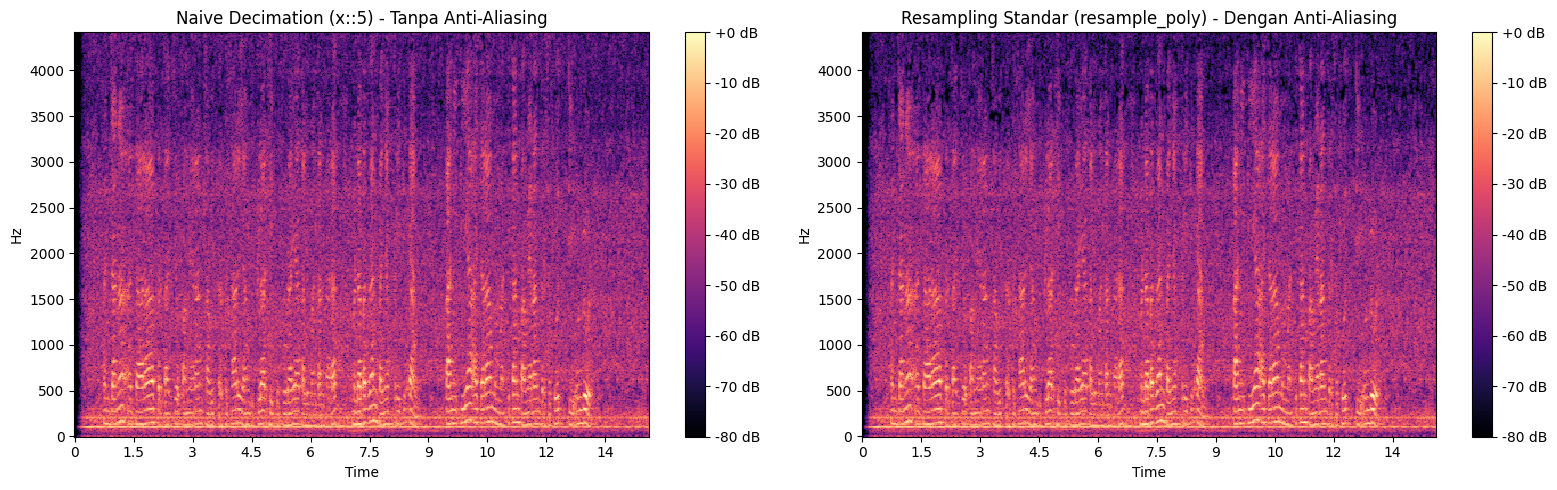

In [3]:
# ============================================================
# CELL 3: DOWNSAMPLING - NAIVE DECIMATION vs RESAMPLING STANDAR
# ============================================================

# Faktor downsampling (M) -> semakin besar M, semakin rendah sample rate hasil downsampling
# Contoh: M=4 berarti sample rate baru = sr_asli / 4
M = 5

# Sample rate target setelah downsampling (dipakai untuk kedua skenario agar adil dibandingkan)
sr_target = sr // M
print(f"Sample rate asli   : {sr} Hz")
print(f"Sample rate target : {sr_target} Hz (faktor M = {M})")
print(f"Jumlah sample      : {len(y)}")

# ------------------------------------------------------------------
# SKENARIO 1: NAIVE DECIMATION (x::M)
# Mengambil setiap sample ke-M secara langsung TANPA low-pass filter (LPF) anti-aliasing.
# Karena tidak ada filter yang membuang komponen frekuensi tinggi sebelum decimation,
# komponen frekuensi di atas Nyquist baru (sr_target/2) akan ter-"lipat" (aliasing)
# dan muncul sebagai frekuensi palsu (artefak) di hasil.
# ------------------------------------------------------------------

# Slicing array dengan step M -> mengambil sample ke-0, ke-M, ke-2M, dst.
y_naive = y[::M]

print(f"\n[Naive Decimation] Jumlah sample setelah downsampling: {len(y_naive)}")

# ------------------------------------------------------------------
# SKENARIO 2: RESAMPLING STANDAR (dengan anti-aliasing)
# scipy.signal.resample_poly menerapkan LPF anti-aliasing (FIR filter) SEBELUM
# melakukan downsampling, sehingga komponen frekuensi tinggi yang berpotensi
# menyebabkan aliasing dibuang terlebih dahulu.
# ------------------------------------------------------------------

# resample_poly membutuhkan rasio up/down dalam bentuk integer sederhana.
# Karena kita hanya melakukan downsampling murni, up = 1 dan down = M.
y_resampled = signal.resample_poly(y, up=1, down=M)

print(f"[Resampling Standar] Jumlah sample setelah downsampling: {len(y_resampled)}")

# (Alternatif lain yang setara secara konsep, menggunakan librosa, dikomentari agar tidak dobel proses)
# y_resampled_librosa = librosa.resample(y, orig_sr=sr, target_sr=sr_target)

# ------------------------------------------------------------------
# PUTAR HASIL KEDUA SKENARIO UNTUK PERBANDINGAN PENDENGARAN
# ------------------------------------------------------------------
print("\nAudio hasil Naive Decimation (berpotensi terdengar 'pecah'/berisik akibat aliasing):")
display(Audio(y_naive, rate=sr_target))

print("Audio hasil Resampling Standar (lebih bersih karena sudah difilter anti-aliasing):")
display(Audio(y_resampled, rate=sr_target))

# ------------------------------------------------------------------
# BANDINGKAN SPEKTROGRAM KEDUA SKENARIO SECARA VISUAL
# ------------------------------------------------------------------
# Gunakan parameter STFT yang lebih kecil karena sample rate sudah menurun
N_FFT_DS = 1024
HOP_LENGTH_DS = 256

# Siapkan 1 baris 2 kolom untuk membandingkan kedua spektrogram berdampingan
fig2, axs2 = plt.subplots(1, 2, figsize=(16, 5))

# --- Spektrogram hasil Naive Decimation ---
D_naive = librosa.stft(y_naive, n_fft=N_FFT_DS, hop_length=HOP_LENGTH_DS)
S_db_naive = librosa.amplitude_to_db(np.abs(D_naive), ref=np.max)
img3 = librosa.display.specshow(
    S_db_naive, sr=sr_target, hop_length=HOP_LENGTH_DS,
    x_axis="time", y_axis="hz", ax=axs2[0], cmap="magma"
)
fig2.colorbar(img3, ax=axs2[0], format="%+2.0f dB")
axs2[0].set_title(f"Naive Decimation (x::{M}) - Tanpa Anti-Aliasing")

# --- Spektrogram hasil Resampling Standar ---
D_resampled = librosa.stft(y_resampled, n_fft=N_FFT_DS, hop_length=HOP_LENGTH_DS)
S_db_resampled = librosa.amplitude_to_db(np.abs(D_resampled), ref=np.max)
img4 = librosa.display.specshow(
    S_db_resampled, sr=sr_target, hop_length=HOP_LENGTH_DS,
    x_axis="time", y_axis="hz", ax=axs2[1], cmap="magma"
)
fig2.colorbar(img4, ax=axs2[1], format="%+2.0f dB")
axs2[1].set_title("Resampling Standar (resample_poly) - Dengan Anti-Aliasing")

plt.tight_layout()
plt.show()

## Analisis Perbedaan Audio yang telah di Downsampling Menggunakan Naive Decimation dan Resampling Standar
Berdasarkan kemampuan mendengar penulis, tidak ada perbedaan terhadap audio yang telah di downsampling menggunakan Naive Decimation dan Resampling Standar. Namun, berdasarkan spektrogram-spektrogram di atas terdapat beberapa perbedaan.
### Naive Decimation (a)
Spektrogram audio yang telah di downsampling menggunakan Naive Decimation terlihat memiliki banyak gangguan pada frekuensi sekitar 3000 hingga 5000.
### Resampling Standar (b)
Spektrogram audio yang telah di downsampling menggunakan Resampling Standar terlihat memiliki banyak spot hitam tanpa titik di frekuensi sekitar 3000 hingga 5000.

Berdasarkan hal tersebut, seharusnya audio (b) terdengar lebih tajam dibandingkan audio (a). Spektrogram audio (b) juga terlihat lebih mirip dengan spektrogram audio asli daripada audio (a). Sungguh disayangkan kemampuan telinga penulis hanyalah rata-rata sehingga tidak bisa mendengarkan perbedaan tersebut :)

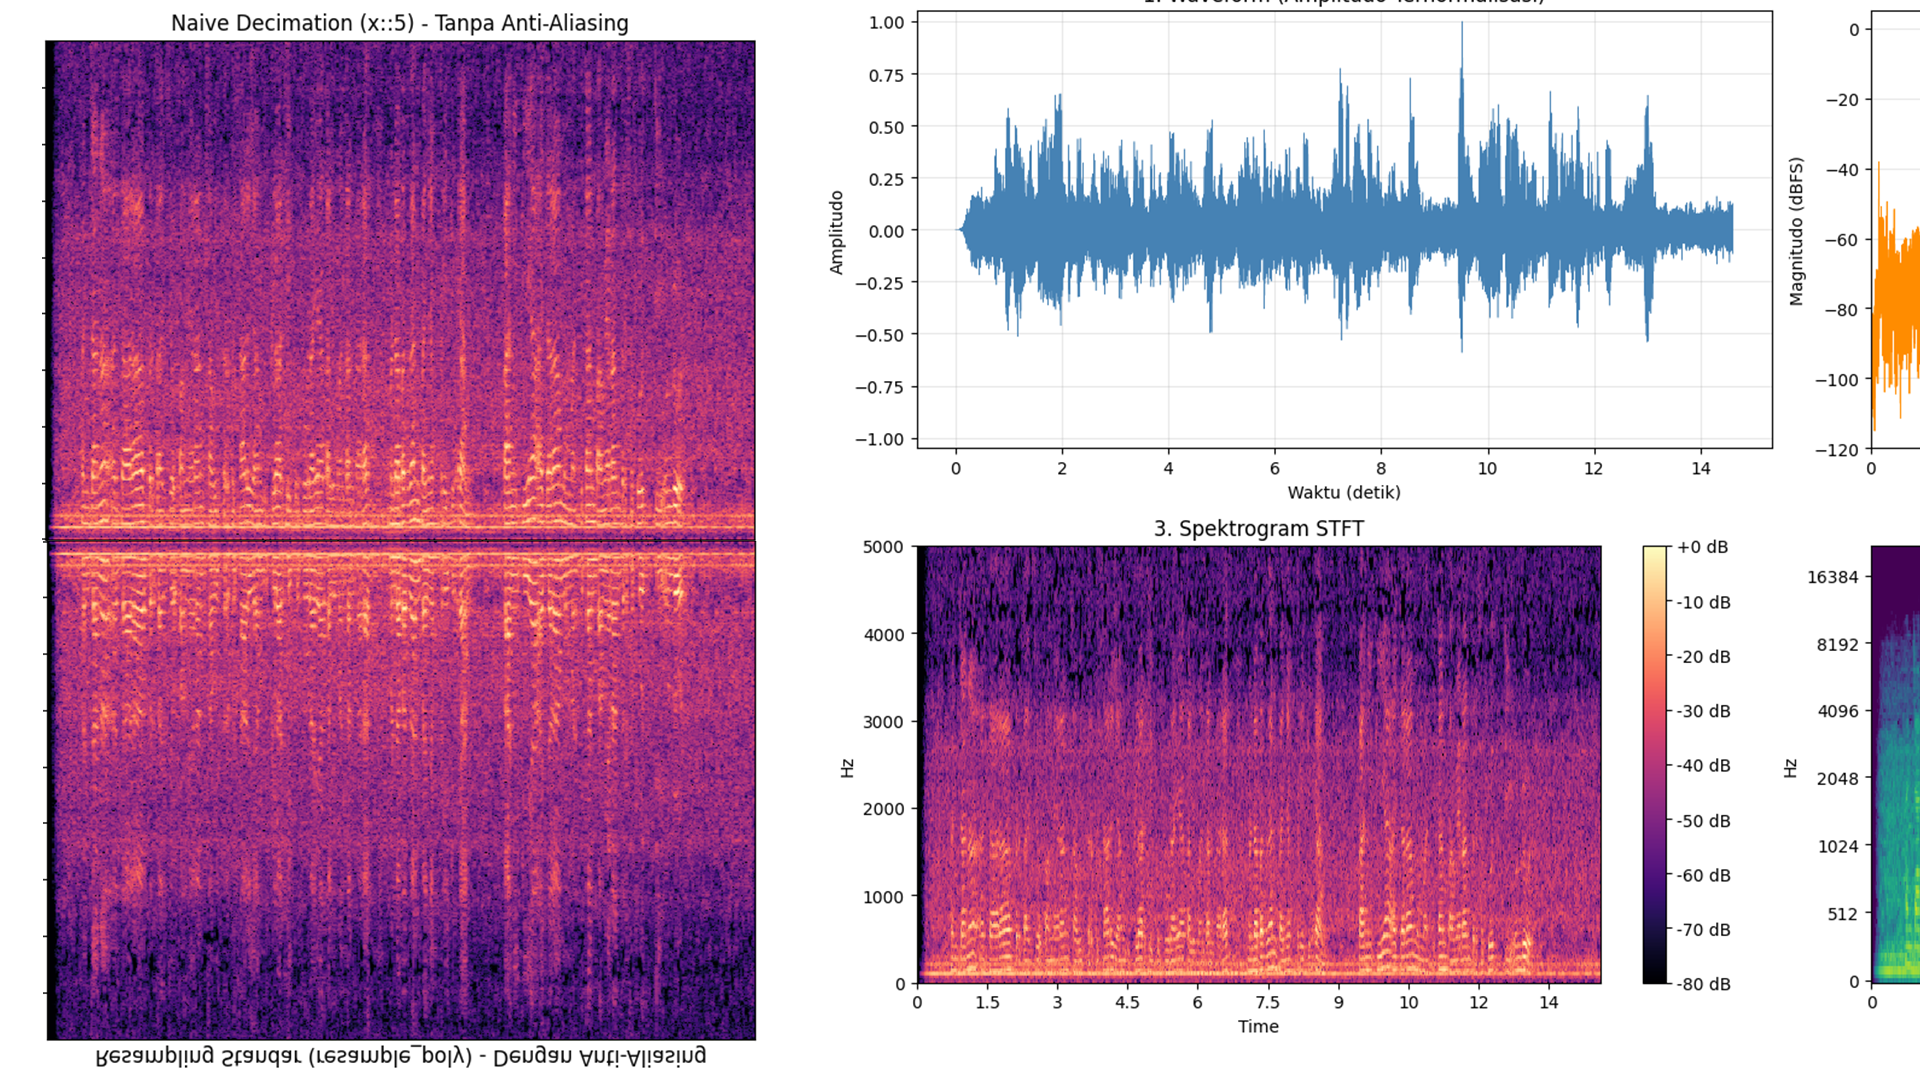

In [4]:
display(Image(filename="spektrogram_asli_dan_downsample.png"))